# toma — toy model of manifolds

data: `x = Σᵢ mᵢ + ε`  where each `mᵢ` is a low-dimensional manifold embedded in ℝᵈ  
recovery: train a TopK SAE, measure how well it reconstructs each `mᵢ`

In [1]:
import numpy as np
import torch
import cmcrameri          # registers managua with matplotlib
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader, TensorDataset
from overcomplete.sae import TopKSAE, train_sae
from toma.dgp import DGP, Circle, Sphere, Torus, Mobius, SwissRoll, Helix, FlatDisk, LineSegment, Concept
from toma.metrics import oracle_k_r2, component_f1
from toma.configs import CONFIGS, SMALL, MEDIUM, LARGE, GIANT

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})

## setup

using the `SMALL` benchmark config (d=128, 10 components, ~30 % concepts).  
to build your own, pass any list of manifolds directly to `DGP`:

In [13]:
cfg = SMALL   # swap for MEDIUM / LARGE / GIANT, or build a custom DGP

np.random.seed(42)
dgp = cfg.build_dgp()

np.random.seed(0)
data = dgp.sample(n=cfg.n_train, l0=cfg.l0, noise=0.0)

x        = data['x']              # (N, d)
contribs = data['contributions']  # (N, M, d)
masks    = data['active_masks']   # (N, M) bool
thetas   = data['thetas']         # list[M], thetas[i]: (n_active_i, intrinsic_dim_i)

M = len(dgp.components)
print(f'd={cfg.d}, M={M}, l0={cfg.l0}, N={cfg.n_train}')
print('components:', [comp.mtype for comp in dgp.components])

d=128, M=10, l0=2, N=20000
components: ['Torus', 'SwissRoll', 'Mobius', 'FlatDisk', 'Helix', 'Circle', 'Sphere', 'Concept', 'Concept', 'Concept']


## manifold zoo

pca of each mᵢ, colored by first intrinsic coordinate (managua)

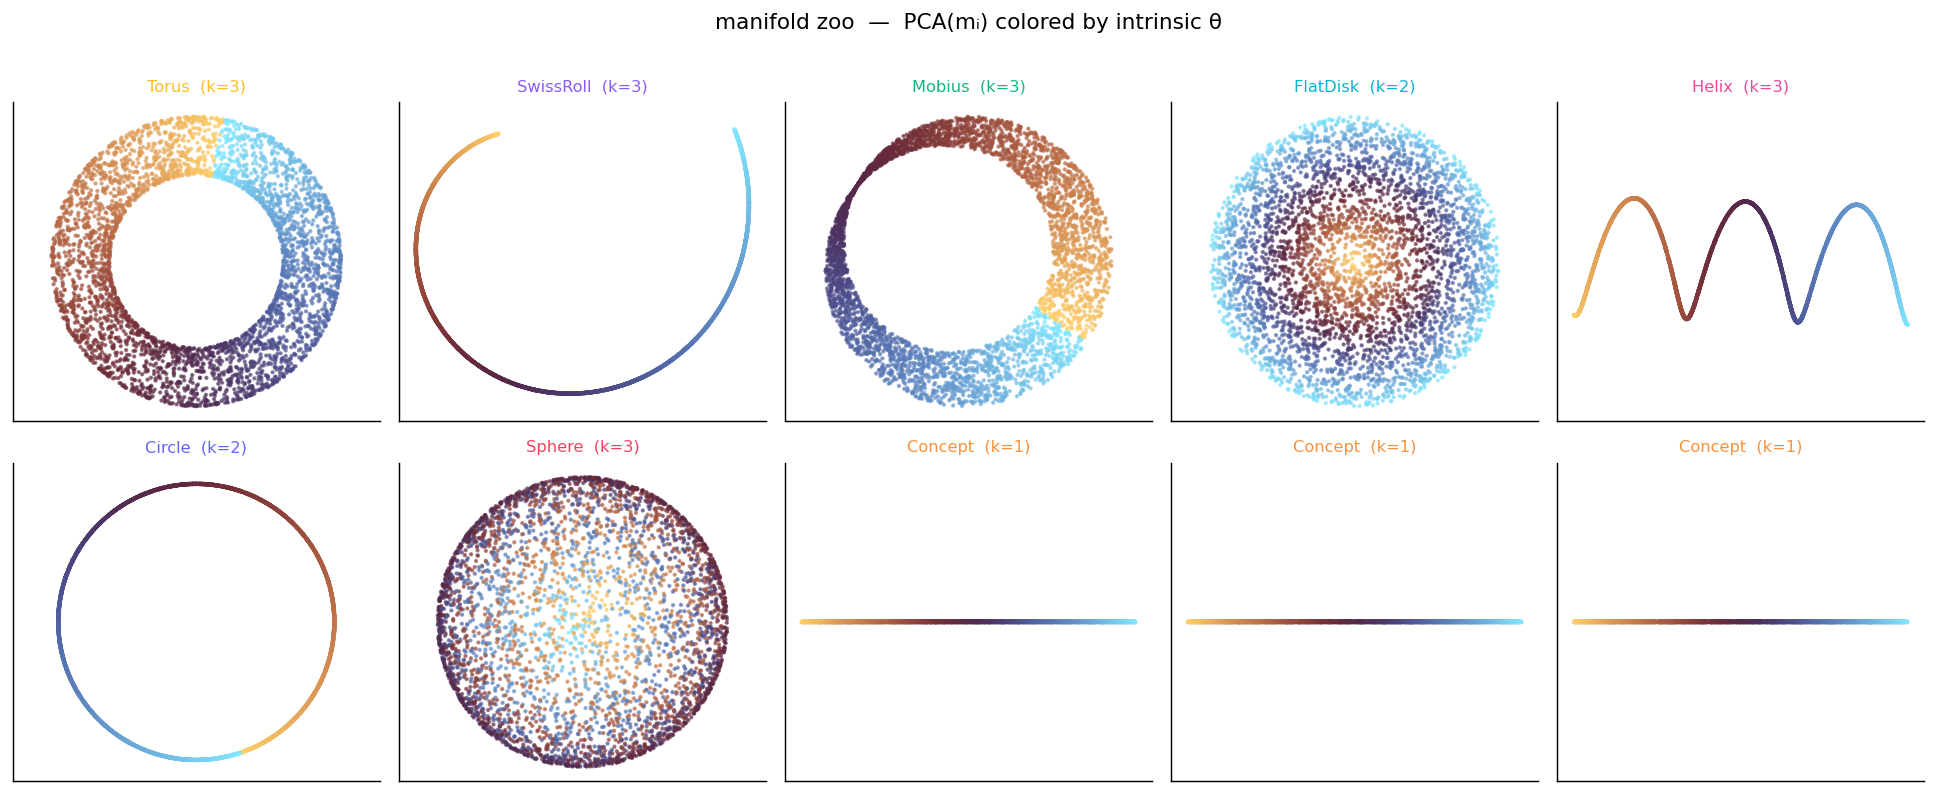

In [16]:
COLORS = {
    'Circle': '#6366f1', 'Sphere': '#f43f5e', 'Torus': '#fbbf24',
    'Mobius': '#10b981', 'SwissRoll': '#8b5cf6', 'Helix': '#ec4899',
    'FlatDisk': '#06b6d4', 'LineSegment': '#a3e635', 'Concept': '#fb923c',
}

ncols = 5
nrows = -(-M // ncols)  # ceiling division

plt.figure(figsize=(ncols * 3, nrows * 3))
for i, comp in enumerate(dgp.components):
    mask  = masks[:, comp.idx]
    mi    = contribs[mask, comp.idx]
    theta = thetas[comp.idx][:, 0]

    xy      = PCA(2).fit_transform(mi)
    t_norm  = (theta - theta.min()) / (theta.max() - theta.min() + 1e-9)

    plt.subplot(nrows, ncols, i + 1)
    plt.scatter(xy[:, 0], xy[:, 1], c=t_norm, cmap='managua', s=2, alpha=0.6, rasterized=True)
    plt.title(f'{comp.mtype}  (k={comp.ambient_dim})', color=COLORS[comp.mtype], fontsize=9)
    plt.axis('equal')
    plt.xticks([])
    plt.yticks([])

plt.suptitle('manifold zoo  —  PCA(mᵢ) colored by intrinsic θ', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

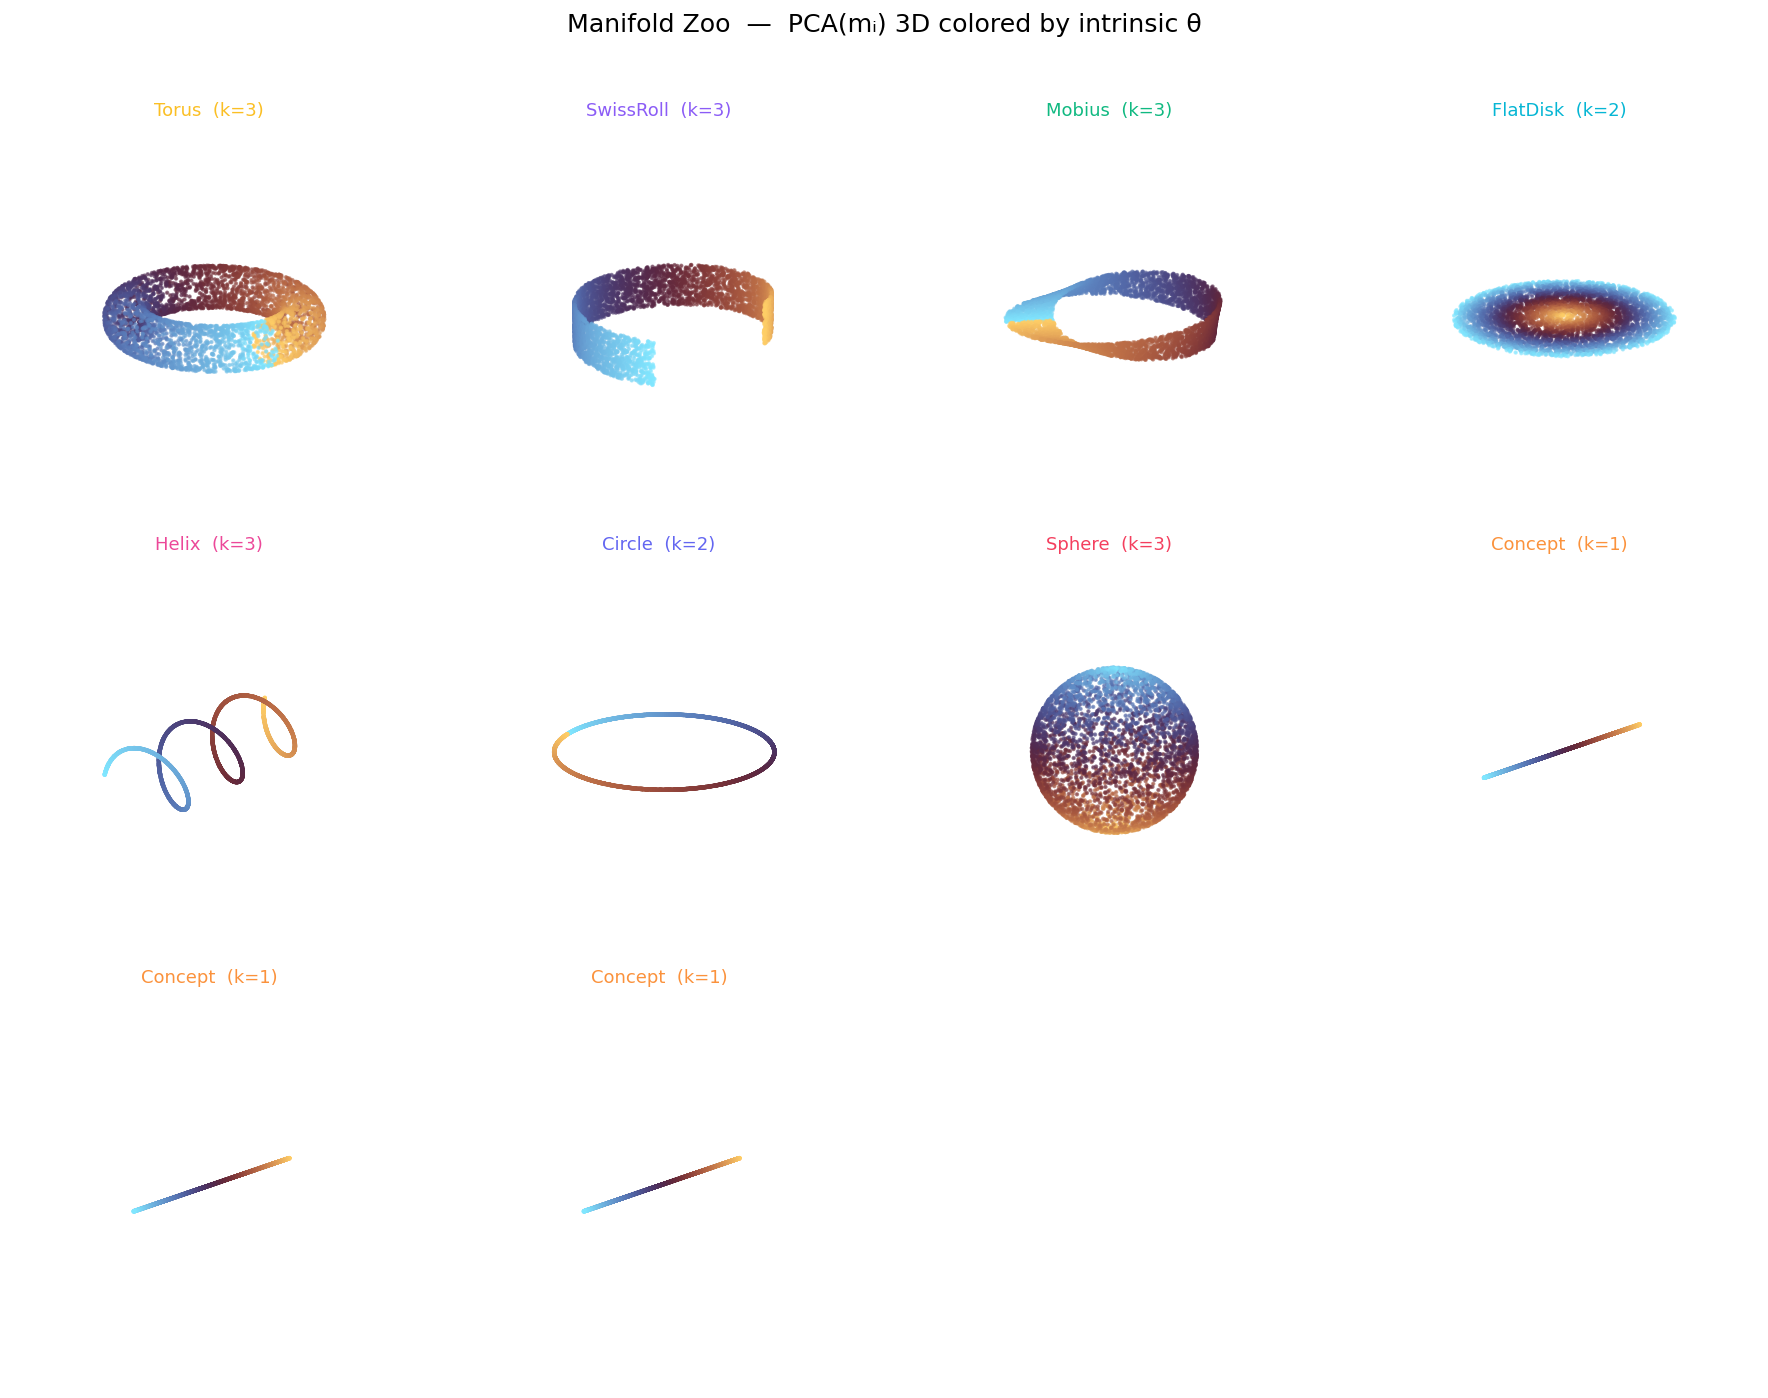

In [26]:
COLORS = {
    'Circle': '#6366f1', 'Sphere': '#f43f5e', 'Torus': '#fbbf24',
    'Mobius': '#10b981', 'SwissRoll': '#8b5cf6', 'Helix': '#ec4899',
    'FlatDisk': '#06b6d4', 'LineSegment': '#a3e635', 'Concept': '#fb923c',
}

ncols = 4
nrows = -(-M // ncols)

plt.figure(figsize=(ncols * 3.5, nrows * 3.5))

for i, comp in enumerate(dgp.components):
    mask  = masks[:, comp.idx]
    mi    = contribs[mask, comp.idx]
    theta = thetas[comp.idx][:, 0]

    xyz = PCA(3).fit_transform(mi)
    t_norm  = (theta - theta.min()) / (theta.max() - theta.min() + 1e-9)

    plt.subplot(nrows, ncols, i + 1, projection='3d')

    plt.gca().scatter(
        xyz[:, 0], xyz[:, 1], xyz[:, 2],
        c=t_norm, cmap='managua', s=2, alpha=0.6, rasterized=True
    )

    plt.gca().view_init(elev=20, azim=45)
    plt.axis('equal')

    plt.title(f'{comp.mtype}  (k={comp.ambient_dim})', color=COLORS.get(comp.mtype, 'black'), fontsize=10)
    plt.axis('off')

plt.suptitle('Manifold Zoo  —  PCA(mᵢ) 3D colored by intrinsic θ', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## mixture

pca of x = Σᵢ mᵢ, colored by dominant component (largest ‖mᵢ‖)

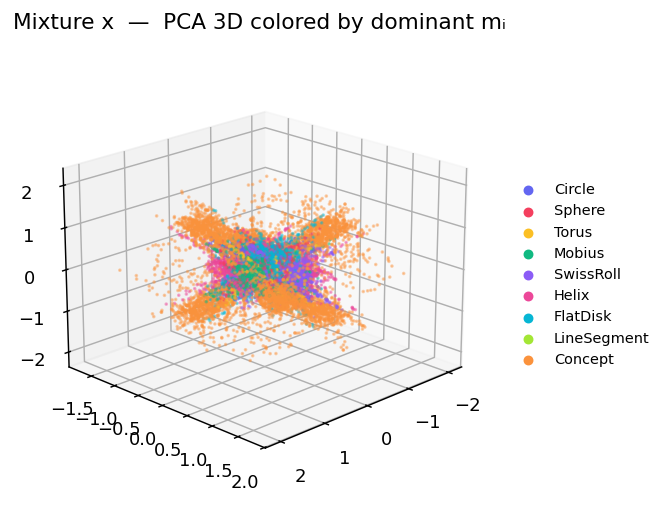

In [29]:
norms = np.linalg.norm(contribs, axis=2)
norms[~masks] = 0
dominant = norms.argmax(1)

xyz = PCA(3).fit_transform(x)
point_colors = [COLORS[dgp.components[i].mtype] for i in dominant]

plt.figure(figsize=(6, 4))
plt.subplot(1, 1, 1, projection='3d')
plt.gca().scatter(
    xyz[:, 0], xyz[:, 1], xyz[:, 2],
    c=point_colors, s=1, alpha=0.4, rasterized=True
)

plt.gca().view_init(elev=20, azim=45)
plt.axis('equal')
for mtype, c in COLORS.items():
    plt.scatter([], [], c=c, s=20, label=mtype)

plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=8, frameon=False)
plt.title('Mixture x  —  PCA 3D colored by dominant mᵢ', pad=15)

plt.tight_layout()
plt.show()

## sae training

topk sae from [overcomplete](https://github.com/KempnerInstitute/overcomplete)

In [31]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def criterion(x, x_hat, pre_codes, codes, dictionary):
    reconstruction_loss = (x - x_hat).square().mean()

    is_dead = ((codes > 0).sum(dim=0) == 0).float().detach()
    reanim_loss = (pre_codes * is_dead[None, :]).mean()

    loss = reconstruction_loss - 1e-3 * reanim_loss
    return loss

torch.manual_seed(0)
sae       = TopKSAE(input_shape=cfg.d, nb_concepts=cfg.sae_width, top_k=8, device=DEVICE)
loader    = DataLoader(TensorDataset(torch.from_numpy(x)), batch_size=512, shuffle=True)
optimizer = torch.optim.Adam(sae.parameters(), lr=3e-3)
logs      = train_sae(sae, loader, criterion, optimizer, nb_epochs=10, device=DEVICE, monitoring=1)

Epoch[1/10], Loss: 0.0084, R2: 0.4668, L0: 8.0000, Dead Features: 0.0%, Time: 1.1175 seconds


Epoch[2/10], Loss: 0.0012, R2: 0.9229, L0: 8.0000, Dead Features: 0.4%, Time: 1.4048 seconds
Epoch[3/10], Loss: 0.0003, R2: 0.9823, L0: 8.0000, Dead Features: 0.0%, Time: 1.9153 seconds
Epoch[4/10], Loss: 0.0001, R2: 0.9917, L0: 8.0000, Dead Features: 0.0%, Time: 1.4807 seconds
Epoch[5/10], Loss: 0.0001, R2: 0.9946, L0: 8.0000, Dead Features: 0.0%, Time: 0.8918 seconds
Epoch[6/10], Loss: 0.0001, R2: 0.9966, L0: 8.0000, Dead Features: 0.0%, Time: 0.9205 seconds
Epoch[7/10], Loss: 0.0000, R2: 0.9974, L0: 8.0000, Dead Features: 0.0%, Time: 0.8952 seconds
Epoch[8/10], Loss: 0.0000, R2: 0.9978, L0: 8.0000, Dead Features: 0.0%, Time: 0.7083 seconds
Epoch[9/10], Loss: 0.0000, R2: 0.9980, L0: 8.0000, Dead Features: 0.0%, Time: 1.2770 seconds
Epoch[10/10], Loss: 0.0000, R2: 0.9982, L0: 8.0000, Dead Features: 0.0%, Time: 0.8130 seconds


In [32]:
sae.eval()
with torch.no_grad():
    pre_codes, codes = sae.encode(torch.from_numpy(x).to(DEVICE))
codes      = codes.cpu().numpy()   # (N, sae_width) sparse
dictionary = sae.get_dictionary().cpu().detach().numpy()  # (sae_width, d)

print(f'codes: {codes.shape},  sparsity: {(codes > 0).mean():.3f}  (expected {cfg.sae_k / cfg.sae_width:.3f})')

codes: (20000, 256),  sparsity: 0.031  (expected 0.016)


## recovery metrics

**oracle R²** — for component i with known ambient dim kᵢ, reconstruct mᵢ using only its top kᵢ SAE atoms  
**best-atom F1** — find the SAE atom whose on/off firing best predicts when mᵢ is active

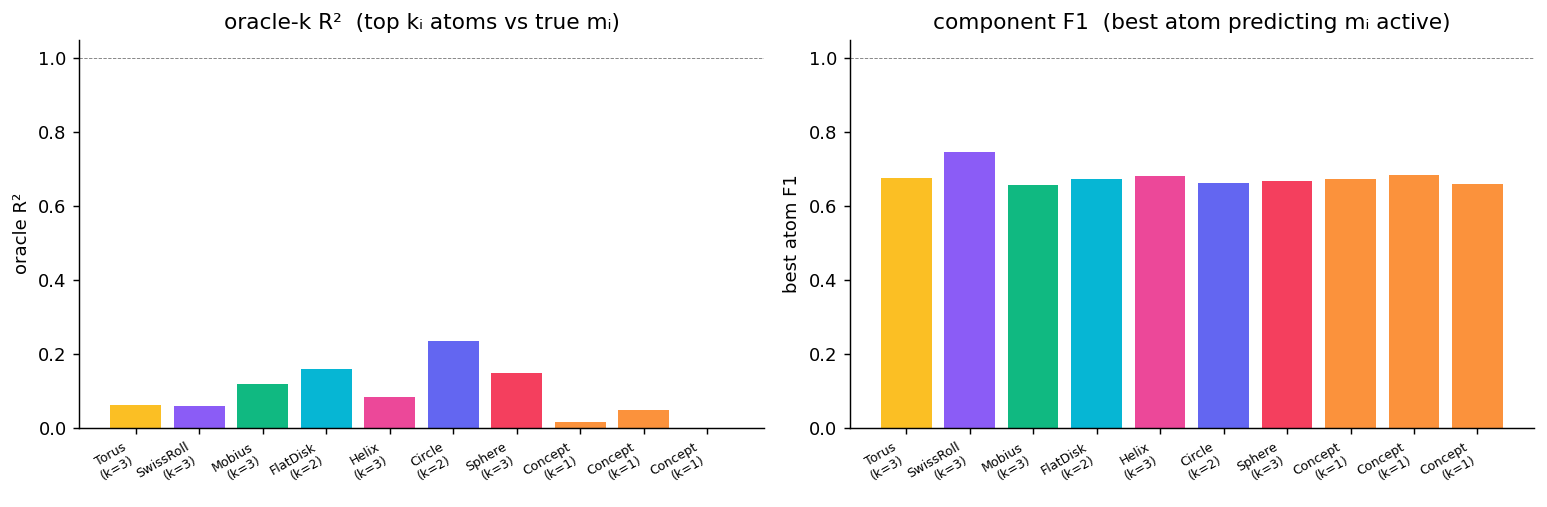

component          k   oracle_r2       f1
Torus              3       0.061    0.677
SwissRoll          3       0.060    0.748
Mobius             3       0.118    0.658
FlatDisk           2       0.159    0.673
Helix              3       0.083    0.683
Circle             2       0.234    0.662
Sphere             3       0.149    0.669
Concept            1       0.017    0.673
Concept            1       0.047    0.685
Concept            1      -0.143    0.660


In [33]:
r2    = oracle_k_r2(codes, dictionary, contribs, masks, dgp.components)
f1, _ = component_f1(codes, masks, dgp.components)

labels = [f'{comp.mtype}\n(k={comp.ambient_dim})' for comp in dgp.components]
c_arr  = [COLORS[comp.mtype] for comp in dgp.components]
xs     = np.arange(M)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(xs, r2, color=c_arr)
plt.xticks(xs, labels, fontsize=7, rotation=30, ha='right')
plt.ylim(0, 1.05)
plt.ylabel('oracle R²')
plt.title('oracle-k R²  (top kᵢ atoms vs true mᵢ)')
plt.axhline(1, color='gray', lw=0.5, ls='--')

plt.subplot(1, 2, 2)
plt.bar(xs, f1, color=c_arr)
plt.xticks(xs, labels, fontsize=7, rotation=30, ha='right')
plt.ylim(0, 1.05)
plt.ylabel('best atom F1')
plt.title('component F1  (best atom predicting mᵢ active)')
plt.axhline(1, color='gray', lw=0.5, ls='--')

plt.tight_layout()
plt.show()

print(f'{"component":<15}  {"k":>3}   {"oracle_r2":>9}   {"f1":>6}')
for comp, r, f in zip(dgp.components, r2, f1):
    print(f'{comp.mtype:<15}  {comp.ambient_dim:>3}   {r:>9.3f}   {f:>6.3f}')